In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [10]:
import numpy as np

In [2]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(nav.shape)
print(performance.shape)

(46000, 3)
(40, 19)


In [3]:
print(nav.columns.tolist())
print(performance.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [4]:

nav['date'] = pd.to_datetime(nav['date'])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [5]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [6]:
print(nav.dtypes)

amfi_code                int64
date            datetime64[us]
nav                    float64
daily_return           float64
dtype: object


In [ ]:
nav['date'] = pd.to_datetime(nav['date'])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [7]:
cagr_data = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code]

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    years = (
        temp['date'].max()
        - temp['date'].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    ) * 100

    cagr_data.append(
        [code, round(cagr, 2)]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        'amfi_code',
        'cagr_pct'
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.64
1,100025,4.46
2,100033,30.10
3,101206,23.52
4,101207,7.93


In [8]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("cagr_report.csv saved")

cagr_report.csv saved


In [12]:
risk_free_rate = 0.065

sharpe_data = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == code
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    if len(returns) == 0:
        continue

    sharpe = (
        (
            returns.mean()
            -
            (risk_free_rate / 252)
        )
        /
        returns.std()
    ) * np.sqrt(252)

    sharpe_data.append(
        [code, round(sharpe, 4)]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.2015
1,100025,-0.5671
2,100033,1.0937
3,101206,1.0272
4,101207,0.1627


In [13]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved")

sharpe_values.csv saved


In [14]:
from scipy.stats import linregress

alpha_beta_data = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code]

    returns = temp['daily_return'].dropna()

    if len(returns) < 30:
        continue

    # Dummy benchmark (using mean return as proxy)
    benchmark = returns.mean()

    slope, intercept, r, p, std = linregress(
        range(len(returns)),
        returns
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_data.append(
        [code, round(alpha, 4), round(beta, 4)]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_data,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.0628,-0.0
1,100025,0.0466,-0.0
2,100033,0.1759,0.0
3,101206,0.0279,0.0
4,101207,0.4254,-0.0


In [15]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [16]:
drawdown_data = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code].copy()

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav']
        -
        temp['running_max']
    ) / temp['running_max']

    max_dd = temp['drawdown'].min()

    drawdown_data.append(
        [code, round(max_dd * 100, 2)]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        'amfi_code',
        'max_drawdown_pct'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [17]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [18]:
sortino_df.head()

NameError: name 'sortino_df' is not defined

In [19]:
risk_free_rate = 0.065

sortino_data = []

for code in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == code]

    returns = temp['daily_return'].dropna()

    downside = returns[returns < 0]

    if len(downside) == 0:
        continue

    sortino = (
        (
            returns.mean()
            - (risk_free_rate / 252)
        )
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_data.append(
        [code, round(sortino, 4)]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.3510
1,100025,-0.9418
2,100033,1.8291
3,101206,1.7996
4,101207,0.2766


In [20]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("sortino_values.csv saved")

sortino_values.csv saved


In [21]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
)

scorecard['score'] = (
    scorecard['cagr_pct'].rank(pct=True) * 30 +
    scorecard['sharpe_ratio'].rank(pct=True) * 25 +
    scorecard['alpha'].rank(pct=True) * 20 +
    (-scorecard['max_drawdown_pct']).rank(pct=True) * 25
)

scorecard = scorecard.sort_values(
    'score',
    ascending=False
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,max_drawdown_pct,score
25,120505,32.80,1.1801,0.3813,-18.19,87.125
21,119598,32.40,0.9453,0.3470,-28.71,87.125
39,149324,32.26,0.9498,0.1829,-31.17,81.625
36,148569,31.92,1.2349,0.2655,-16.40,79.125
38,149323,29.56,1.1321,0.2806,-17.25,76.875


In [22]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


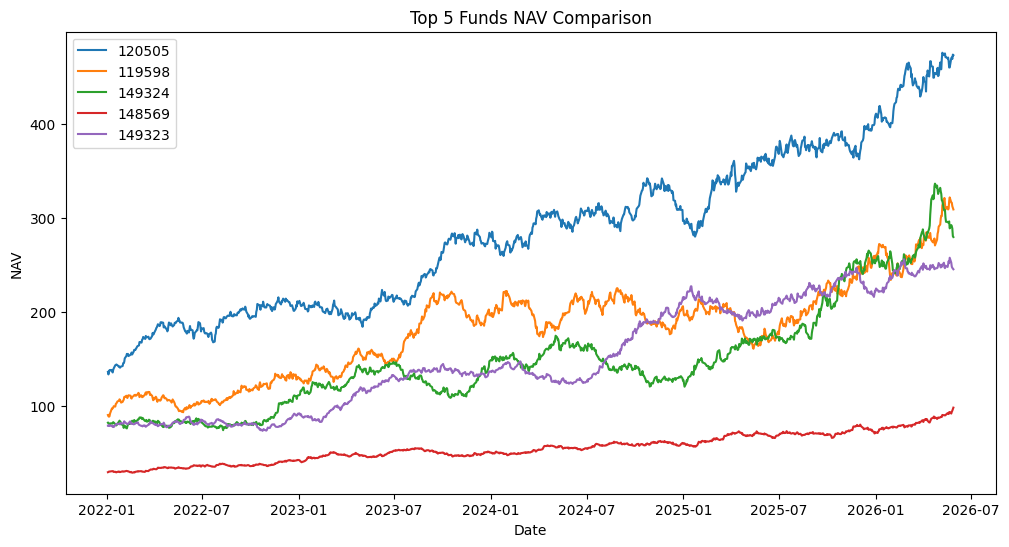

In [23]:
top5 = scorecard.head(5)['amfi_code'].tolist()

plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

benchmark_chart.png saved


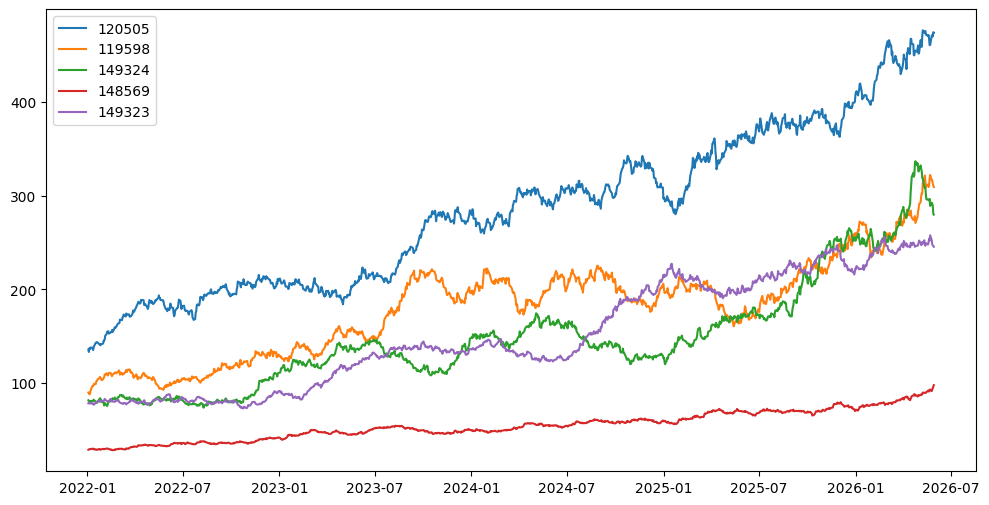

In [24]:
plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.legend()

plt.savefig(
    "../data/processed/benchmark_chart.png"
)

print("benchmark_chart.png saved")